# Etapa 2 · Modelado con validación segura, exportación del modelo y monitoreo

Este cuaderno contiene:

1. División de los datos **antes** del escalado.
2. `Pipeline` + `GridSearchCV` con validación cruzada estratificada.
3. Evaluación del modelo elegido: matriz de confusión, curva ROC y AUC.
4. Exportación del modelo para la API (Etapa 3).
5. Reporte de deriva de datos con Evidently (Etapa 6).

In [1]:
import sys  # Acceso a la configuración del intérprete de Python
sys.path.insert(0, "..")  # Agrega la carpeta raíz del proyecto para poder importar el paquete src
import shutil  # Copia de archivos
import warnings  # Control de mensajes de advertencia
import joblib  # Guardado y carga del modelo entrenado
import numpy as np  # Cálculo numérico
import pandas as pd  # Manejo de tablas de datos
import matplotlib.pyplot as plt  # Creación de gráficos
from sklearn.inspection import permutation_importance  # Importancia de variables por permutación
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix, roc_auc_score, roc_curve  # Métricas y gráficos de evaluación
from evidently.metric_preset import DataDriftPreset  # Conjunto de métricas de deriva de datos de Evidently
from evidently.report import Report  # Generador de reportes de Evidently
from src import modelado as mod  # Funciones reutilizables del proyecto

warnings.filterwarnings("ignore")  # Oculta advertencias que no afectan los resultados
pd.set_option("display.width", 160)  # Ancho de impresión de las tablas

## 1. División de los datos antes de cualquier transformación

In [2]:
X, y = mod.cargar_datos()  # Carga las 11 variables clínicas y el objetivo HeartDisease
X_train, X_test, y_train, y_test = mod.dividir_datos(X, y)  # Partición 80/20 estratificada con semilla fija
print(f"Train: {X_train.shape[0]} pacientes ({y_train.mean():.1%} con enfermedad)")  # Tamaño y balance del conjunto de entrenamiento
print(f"Test:  {X_test.shape[0]} pacientes ({y_test.mean():.1%} con enfermedad)")  # Tamaño y balance del conjunto de prueba

Train: 734 pacientes (55.3% con enfermedad)
Test:  184 pacientes (55.4% con enfermedad)


El conjunto de prueba queda apartado desde este momento. La mediana para imputar, los
mínimos y máximos del escalado y las categorías del *one-hot* se aprenden solo con train
(y, dentro de la validación cruzada, solo con los pliegues de entrenamiento).

## 2. `Pipeline` + `GridSearchCV`

El `Pipeline` tiene dos pasos: `prep` (preprocesamiento) y `clf` (clasificador).

In [3]:
mod.construir_preprocesador()  # Muestra el diagrama del preprocesador: imputación de ceros, escalado MinMax y one-hot

ColumnTransformer(transformers=[('ceros',
                                 Pipeline(steps=[('imputar',
                                                  SimpleImputer(add_indicator=True,
                                                                missing_values=0,
                                                                strategy='median')),
                                                 ('escalar', MinMaxScaler())]),
                                 ['RestingBP', 'Cholesterol']),
                                ('numericas', MinMaxScaler(),
                                 ['Age', 'FastingBS', 'MaxHR', 'Oldpeak']),
                                ('categoricas',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['Sex', 'ChestPainType', 'RestingECG',
                                  'ExerciseAngina', 'ST_Slope'])])

In [4]:
ranking, busquedas = mod.comparar_modelos(X_train, y_train, X_test, y_test)  # Entrena los siete modelos con validación cruzada de 5 pliegues
ranking[["modelo", "auc_cv", "auc_test", "accuracy_test", "recall_test", "mejores_parametros"]].round(4)  # Ranking por AUC de validación cruzada

  File "C:\DanielSR\Projects\proyecto_heart_disease\.venv\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "C:\Users\user-pc\.conda\envs\ml_venv\lib\subprocess.py", line 505, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Users\user-pc\.conda\envs\ml_venv\lib\subprocess.py", line 951, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\user-pc\.conda\envs\ml_venv\lib\subprocess.py", line 1436, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


,modelo,auc_cv,auc_test,accuracy_test,recall_test,mejores_parametros
posicion,,,,,,
1,RandomForest,0.9345,0.9304,0.8967,0.9412,"{'clf__max_depth': None, 'clf__min_samples_lea..."
2,GradientBoosting,0.9295,0.9306,0.9076,0.9412,"{'clf__learning_rate': 0.05, 'clf__max_depth':..."
3,LogisticRegression,0.9287,0.9304,0.8859,0.9216,{'clf__C': 1}
4,SVC,0.9269,0.9374,0.8804,0.9216,"{'clf__C': 1, 'clf__gamma': 0.1}"
5,KNN,0.9245,0.9402,0.9130,0.9412,"{'clf__n_neighbors': 31, 'clf__weights': 'dist..."
6,NaiveBayes,0.9151,0.9099,0.8859,0.9118,{'clf__var_smoothing': 1e-09}
7,DecisionTree,0.9087,0.8821,0.7772,0.8137,"{'clf__max_depth': 5, 'clf__min_samples_leaf':..."


In [5]:
nombre_mejor = ranking.iloc[0]["modelo"]  # Modelo con mayor AUC de validación cruzada (elegido SIN mirar el test)
grid_mejor = busquedas[nombre_mejor]  # Búsqueda ajustada de ese modelo
modelo_final = grid_mejor.best_estimator_  # Pipeline completo (preprocesamiento + clasificador) reentrenado con todo train
print(f"Modelo elegido: {nombre_mejor}")  # Nombre del modelo ganador
print(f"Hiperparámetros: {grid_mejor.best_params_}")  # Hiperparámetros ganadores
print(f"AUC de validación cruzada: {grid_mejor.best_score_:.4f}")  # Desempeño estimado con train
detalle = pd.DataFrame(grid_mejor.cv_results_)[["params", "mean_test_score", "std_test_score", "rank_test_score"]]  # Resultado de cada combinación de hiperparámetros
detalle.sort_values("rank_test_score").head(5)  # Las cinco mejores combinaciones

Modelo elegido: RandomForest
Hiperparámetros: {'clf__max_depth': None, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 300}
AUC de validación cruzada: 0.9345


,params,mean_test_score,std_test_score,rank_test_score
11,"{'clf__max_depth': None, 'clf__min_samples_lea...",0.934465,0.028179,1
10,"{'clf__max_depth': None, 'clf__min_samples_lea...",0.934311,0.027869,2
7,"{'clf__max_depth': 8, 'clf__min_samples_leaf':...",0.933567,0.027464,3
6,"{'clf__max_depth': 8, 'clf__min_samples_leaf':...",0.933301,0.026512,4
2,"{'clf__max_depth': 4, 'clf__min_samples_leaf':...",0.932732,0.028395,5


## 3. Evaluación en el conjunto de prueba

### AUC y reporte de clasificación

In [6]:
proba_test = modelo_final.predict_proba(X_test)[:, 1]  # Probabilidad de enfermedad para cada paciente de test
pred_test = modelo_final.predict(X_test)  # Clase predicha con umbral 0.5
auc_test = roc_auc_score(y_test, proba_test)  # Área bajo la curva ROC en test
print(f"AUC en test: {auc_test:.4f}\n")  # Reporta el AUC
print(classification_report(y_test, pred_test, target_names=["Sano (0)", "Enfermedad (1)"]))  # Precisión, recall y F1 por clase

AUC en test: 0.9304

                precision    recall  f1-score   support

      Sano (0)       0.92      0.84      0.88        82
Enfermedad (1)       0.88      0.94      0.91       102

      accuracy                           0.90       184
     macro avg       0.90      0.89      0.89       184
  weighted avg       0.90      0.90      0.90       184



### Matriz de confusión

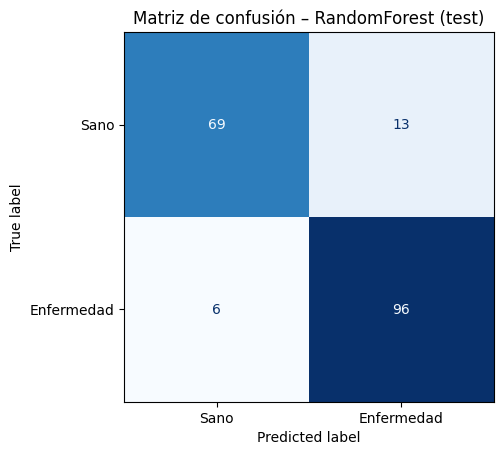

Verdaderos negativos: 69 | Falsos positivos: 13 | Falsos negativos: 6 | Verdaderos positivos: 96
Sensibilidad (recall): 0.941 | Especificidad: 0.841


In [7]:
matriz = confusion_matrix(y_test, pred_test)  # Tabla de aciertos y errores: filas = clase real, columnas = clase predicha
ConfusionMatrixDisplay(matriz, display_labels=["Sano", "Enfermedad"]).plot(cmap="Blues", colorbar=False)  # Dibuja la matriz
plt.title(f"Matriz de confusión – {nombre_mejor} (test)")  # Título
plt.grid(False)  # Quita la cuadrícula superpuesta
plt.show()  # Muestra el gráfico
tn, fp, fn, tp = matriz.ravel()  # Extrae las cuatro celdas
print(f"Verdaderos negativos: {tn} | Falsos positivos: {fp} | Falsos negativos: {fn} | Verdaderos positivos: {tp}")  # Resumen numérico
print(f"Sensibilidad (recall): {tp / (tp + fn):.3f} | Especificidad: {tn / (tn + fp):.3f}")  # Tasas de detección de enfermos y de sanos

### Curva ROC

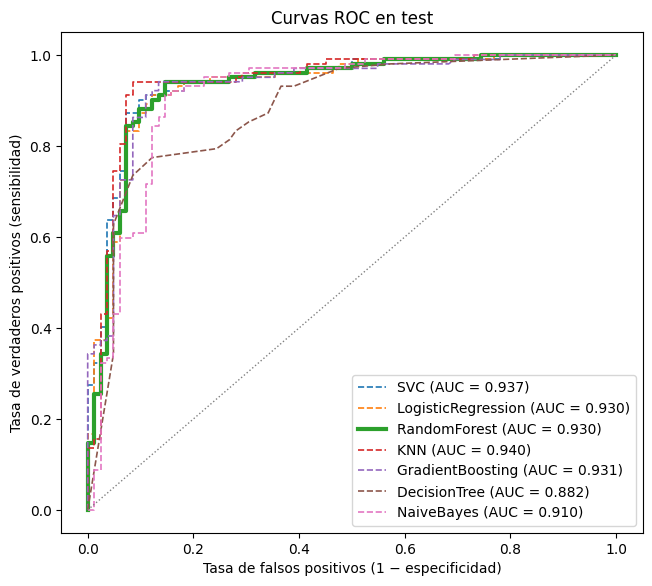

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 6.5))  # Figura para las curvas ROC
for nombre, grid in busquedas.items():  # Recorre los siete modelos
    p = grid.predict_proba(X_test)[:, 1]  # Probabilidades del modelo en test
    fpr, tpr, _ = roc_curve(y_test, p)  # Tasas de falsos y verdaderos positivos para cada umbral
    grosor, estilo = (3, "-") if nombre == nombre_mejor else (1.2, "--")  # Resalta el modelo elegido
    ax.plot(fpr, tpr, lw=grosor, ls=estilo, label=f"{nombre} (AUC = {roc_auc_score(y_test, p):.3f})")  # Dibuja la curva del modelo
ax.plot([0, 1], [0, 1], color="gray", lw=1, ls=":")  # Diagonal de referencia (clasificador al azar)
ax.set_xlabel("Tasa de falsos positivos (1 − especificidad)")  # Eje X
ax.set_ylabel("Tasa de verdaderos positivos (sensibilidad)")  # Eje Y
ax.set_title("Curvas ROC en test")  # Título
ax.legend(loc="lower right")  # Leyenda con el AUC de cada modelo
plt.show()  # Muestra el gráfico

### ¿Qué variables usa el modelo?

Importancia por permutación en test: cuánto cae el AUC al desordenar cada variable.

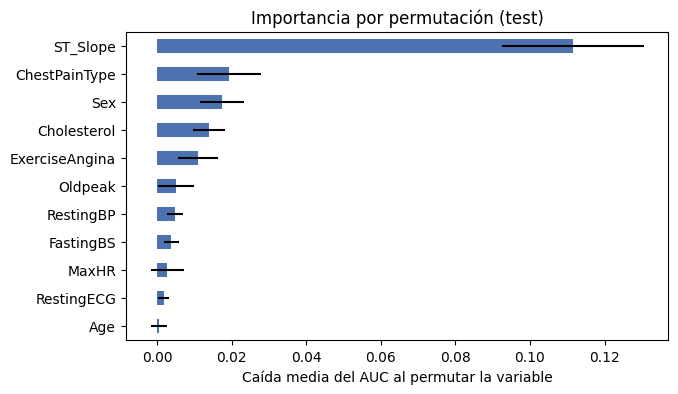

In [9]:
imp = permutation_importance(modelo_final, X_test, y_test, scoring="roc_auc", n_repeats=30, random_state=mod.SEMILLA)  # Permuta cada variable 30 veces y mide la caída de AUC
importancia = pd.DataFrame({"media": imp.importances_mean, "desv": imp.importances_std}, index=X_test.columns).sort_values("media")  # Caída media de AUC y su desviación por variable
importancia["media"].plot.barh(figsize=(7, 4), color="#4C72B0", xerr=importancia["desv"])  # Barras horizontales con barra de error
plt.xlabel("Caída media del AUC al permutar la variable")  # Eje X
plt.title("Importancia por permutación (test)")  # Título
plt.show()  # Muestra el gráfico

**Interpretación de la evaluación.**

* **Modelo elegido:** RandomForest (300 árboles, hojas de al menos 5 pacientes), con AUC de
  validación cruzada 0,9345 ± 0,028. En test obtiene **AUC = 0,930**, casi idéntico: la
  validación cruzada estimó bien el desempeño y no hay señales de sobreajuste.
* **Matriz de confusión (184 pacientes):** 96 verdaderos positivos, 69 verdaderos negativos,
  13 falsos positivos y 6 falsos negativos. La **sensibilidad es 94,1 %** (detecta 96 de 102
  enfermos) y la especificidad 84,1 %. En un tamizaje clínico el error más grave es el
  falso negativo (un enfermo no detectado), así que este balance es razonable; si se quisiera
  reducirlos aún más, bastaría bajar el umbral de 0,5 a costa de más falsos positivos.
* **Curva ROC:** todas las curvas, salvo la del árbol individual, se superponen (AUC entre
  0,91 y 0,94), lo que confirma que la señal está en los datos y no en un algoritmo concreto.
* **Variables:** `ST_Slope` domina con claridad (permutarla reduce el AUC en 0,11),
  seguida de `ChestPainType`, `Sex`, `Cholesterol` y `ExerciseAngina`. Coincide con el
  análisis exploratorio. La edad casi no aporta una vez conocidas las demás variables.

## 4. Exportación del modelo (para la Etapa 3)

Se guarda el `Pipeline` completo: la API recibe los datos crudos del paciente y el propio
modelo aplica el preprocesamiento aprendido en train.

In [10]:
joblib.dump(modelo_final, mod.RUTA_MODELO_API)  # Guarda el Pipeline en app/model.joblib (lo carga la API)
shutil.copyfile(mod.RUTA_MODELO_API, mod.RUTA_MODELO_RAIZ)  # Copia en la raíz del proyecto (estructura de la Etapa 0)
print(f"Modelo guardado: {mod.RUTA_MODELO_API} ({mod.RUTA_MODELO_API.stat().st_size / 1024:.0f} KB)")  # Confirma la ruta y el tamaño
recargado = joblib.load(mod.RUTA_MODELO_API)  # Vuelve a cargar el archivo para verificar que funciona
assert np.allclose(recargado.predict_proba(X_test)[:, 1], proba_test)  # El modelo recargado da exactamente las mismas probabilidades
paciente = X_test.iloc[[0]]  # Un paciente de ejemplo (DataFrame de una fila)
print(paciente.to_dict(orient="records")[0])  # Datos de entrada tal como los recibirá la API
print(f"Probabilidad de enfermedad: {recargado.predict_proba(paciente)[0, 1]:.3f} | etiqueta real: {y_test.iloc[0]}")  # Predicción de ejemplo

Modelo guardado: C:\DanielSR\Projects\proyecto_heart_disease\app\model.joblib (2163 KB)
{'Age': 46, 'Sex': 'M', 'ChestPainType': 'ASY', 'RestingBP': 115, 'Cholesterol': 0, 'FastingBS': 0, 'RestingECG': 'Normal', 'MaxHR': 113, 'ExerciseAngina': 'Y', 'Oldpeak': 1.5, 'ST_Slope': 'Flat'}
Probabilidad de enfermedad: 0.961 | etiqueta real: 1


## 5. Monitoreo de deriva de datos con Evidently (Etapa 6)

Evidently compara la distribución de cada variable entre un conjunto de **referencia**
(train) y uno **actual** (los datos que llegan al modelo). Aquí el conjunto actual es
test, como indica el enunciado; en producción serían las peticiones recibidas por la API.

In [11]:
reporte = Report(metrics=[DataDriftPreset()])  # Reporte con el conjunto estándar de pruebas de deriva
reporte.run(reference_data=X_train, current_data=X_test)  # Compara cada variable de train contra test
reporte.save_html(str(mod.RUTA_REPORTE_DRIFT))  # Guarda el reporte interactivo en drift_report.html


def resumen_deriva(rep):  # Extrae del reporte una tabla resumida por variable
    datos = rep.as_dict()["metrics"]  # Resultados del reporte como diccionario
    general = datos[0]["result"]  # Resumen global: cuántas columnas derivaron
    por_columna = datos[1]["result"]["drift_by_columns"]  # Detalle de cada variable
    tabla = pd.DataFrame(por_columna).T[["stattest_name", "drift_score", "drift_detected"]]  # Prueba usada, valor p o distancia y decisión
    tabla.columns = ["prueba", "puntuación", "deriva"]  # Nombres en español
    print(f"Columnas con deriva: {general['number_of_drifted_columns']} de {general['number_of_columns']} "  # Conteo de columnas con deriva
          f"| ¿deriva del dataset?: {general['dataset_drift']}")  # Decisión global
    return tabla  # Devuelve la tabla resumida


resumen_deriva(reporte)  # Muestra el resumen de train frente a test

Columnas con deriva: 1 de 11 | ¿deriva del dataset?: False


,prueba,puntuación,deriva
Age,K-S p_value,0.072136,False
Cholesterol,K-S p_value,0.017362,True
FastingBS,Z-test p_value,0.544656,False
MaxHR,K-S p_value,0.608245,False
Oldpeak,K-S p_value,0.322876,False
RestingBP,K-S p_value,0.538815,False
ChestPainType,chi-square p_value,0.198885,False
ExerciseAngina,Z-test p_value,0.572223,False
RestingECG,chi-square p_value,0.517262,False
ST_Slope,chi-square p_value,0.314917,False


### Simulación de deriva

Para comprobar que el monitoreo detecta cambios reales, se simula una población distinta:
pacientes 8 años mayores, con colesterol 25 % más alto y con una mezcla diferente de tipos de
dolor torácico.

In [12]:
rng = np.random.default_rng(mod.SEMILLA)  # Generador aleatorio reproducible
X_derivado = X_test.copy()  # Copia de los datos actuales
X_derivado["Age"] = X_derivado["Age"] + 8  # Población más envejecida
X_derivado["Cholesterol"] = (X_derivado["Cholesterol"] * 1.25).round()  # Colesterol más alto (los ceros siguen en cero)
X_derivado["ChestPainType"] = rng.choice(["ASY", "NAP", "ATA", "TA"], size=len(X_derivado), p=[0.25, 0.25, 0.25, 0.25])  # Tipos de dolor repartidos por igual
reporte_sim = Report(metrics=[DataDriftPreset()])  # Nuevo reporte de deriva
reporte_sim.run(reference_data=X_train, current_data=X_derivado)  # Compara train contra la población simulada
reporte_sim.save_html(str(mod.RAIZ / "drift_report_simulado.html"))  # Guarda el segundo reporte
resumen_deriva(reporte_sim)  # Muestra qué variables detecta como derivadas

Columnas con deriva: 3 de 11 | ¿deriva del dataset?: False


,prueba,puntuación,deriva
Age,K-S p_value,0.0,True
Cholesterol,K-S p_value,0.0,True
FastingBS,Z-test p_value,0.544656,False
MaxHR,K-S p_value,0.608245,False
Oldpeak,K-S p_value,0.322876,False
RestingBP,K-S p_value,0.538815,False
ChestPainType,chi-square p_value,0.0,True
ExerciseAngina,Z-test p_value,0.572223,False
RestingECG,chi-square p_value,0.517262,False
ST_Slope,chi-square p_value,0.314917,False


In [13]:
auc_derivado = roc_auc_score(y_test, modelo_final.predict_proba(X_derivado)[:, 1])  # AUC del modelo sobre la población simulada
print(f"AUC en test original: {auc_test:.4f} | AUC con datos derivados: {auc_derivado:.4f}")  # Efecto de la deriva en el desempeño

AUC en test original: 0.9304 | AUC con datos derivados: 0.8824


**Interpretación del monitoreo.**

* **Train frente a test:** Evidently marca deriva en 1 de 11 variables (`Cholesterol`,
  p = 0,017) y concluye que **no hay deriva del dataset**. Es lo esperable: ambos conjuntos
  provienen de la misma partición aleatoria, y al aplicar 11 pruebas al 5 % es normal que alguna
  resulte significativa por azar. Una sola alerta aislada no justifica reentrenar.
* **Población simulada:** detecta correctamente las tres variables alteradas (`Age`,
  `Cholesterol` y `ChestPainType`, con p ≈ 0) y ninguna otra. La regla global de Evidently
  sigue diciendo "sin deriva del dataset" porque exige que derive al menos el 50 % de las
  columnas; por eso conviene vigilar también las variables más importantes para el modelo.
* **Efecto en el modelo:** con los datos derivados el AUC cae de 0,930 a 0,882. La deriva
  de las entradas es una señal temprana de pérdida de desempeño, útil porque en producción
  la etiqueta real (si el paciente enfermó) tarda en conocerse.
* **Uso en producción:** la API debería registrar cada petición; periódicamente se compara
  ese registro con `X_train` usando este mismo reporte, y se reentrena el modelo cuando la
  deriva afecta a variables relevantes o cae el desempeño.